# Genre Classifier
Trains **Logistic Regression**, **SVM**, **Random Forest**, **Naive Bayes**, and **XGBoost** models to classify book genre from 100-word text partitions.

**Inputs required (run the other notebooks first):**
- `partitions.csv` — from `book_partitioner.ipynb`
- `vocabulary.csv` — from `bow.ipynb`

**Outputs:** accuracy scores, classification reports, confusion matrices, and saved model files.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import joblib

## Configuration

In [95]:
PARTITIONS_CSV = "TestingData/partitions.csv"   # output of book_partitioner.ipynb
VOCABULARY_CSV = "FeatureTrainingData/vocabulary.csv"   # output of bow.ipynb

TEST_SIZE      = 0.2    # 80/20 train-test split
RANDOM_STATE   = 42
CV_FOLDS       = 10      # stratified k-fold cross-validation

# Genres in a consistent display order
GENRES = ["biography", "fantasy", "horror", "romance", "sci-fi"]


## Load Data

In [96]:
partitions = pd.read_csv(PARTITIONS_CSV)
vocabulary  = pd.read_csv(VOCABULARY_CSV)["word"].tolist()

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"Vocabulary size   : {len(vocabulary):,} words")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)


Partitions loaded : 5,000 rows
Vocabulary size   : 1,109 words

Genre distribution:
genre
biography    1000
fantasy      1000
horror       1000
romance      1000
sci-fi       1000


,partition_id,book,genre,start_token,text,word_count
0,AutobiographyOfBenjaminFranklin_partition_a,AutobiographyOfBenjaminFranklin,biography,14592,Boston. I took leave of Keimer as going to see...,400
1,AutobiographyOfBenjaminFranklin_partition_b,AutobiographyOfBenjaminFranklin,biography,3278,translated into all the languages of Europe. I...,400
2,AutobiographyOfBenjaminFranklin_partition_c,AutobiographyOfBenjaminFranklin,biography,36048,"in conversation, which makes his company still...",400


## Build Feature Matrix
We use **TF-IDF** restricted to the vocabulary derived from the n-gram analysis.
This ensures the features are exactly the top-100 unigrams we identified per book,
de-duplicated into a shared vocabulary.

In [97]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF restricted to our pre-built vocabulary
vectorizer = TfidfVectorizer(
    vocabulary    = vocabulary,
    sublinear_tf  = True,      # apply log(1+tf) — reduces impact of very frequent words
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'[a-z]+',
    lowercase     = True,
)

X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"  {X.shape[0]} partitions  ×  {X.shape[1]} vocabulary features")


Feature matrix shape: (5000, 1109)
  5000 partitions  ×  1109 vocabulary features


## Train / Test Split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,      # preserve genre proportions in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 4000
Test samples     : 1000


## Model 1 — Logistic Regression

In [99]:
lr = LogisticRegression(
    max_iter      = 1000,
    random_state  = RANDOM_STATE,
    C             = 1.0,
    solver        = 'lbfgs',
    multi_class   = 'multinomial',
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 50)
print(" Logistic Regression — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=GENRES))


 Logistic Regression — Test Set
Accuracy: 0.8930

              precision    recall  f1-score   support

   biography       0.83      0.91      0.86       200
     fantasy       0.93      0.87      0.90       200
      horror       0.83      0.88      0.85       200
     romance       0.96      0.90      0.93       200
      sci-fi       0.93      0.92      0.93       200

    accuracy                           0.89      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.89      0.89      1000



## Model 2 — Support Vector Machine

In [100]:
svm = LinearSVC(
    max_iter     = 2000,
    random_state = RANDOM_STATE,
    C            = 1.0,
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=" * 50)
print(" SVM (LinearSVC) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=GENRES))


 SVM (LinearSVC) — Test Set
Accuracy: 0.8910

              precision    recall  f1-score   support

   biography       0.83      0.89      0.86       200
     fantasy       0.92      0.88      0.90       200
      horror       0.84      0.89      0.86       200
     romance       0.93      0.88      0.90       200
      sci-fi       0.94      0.93      0.93       200

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



## Model 3 — Random Forest

In [101]:
rf = RandomForestClassifier(
    n_estimators = 300,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print(" Random Forest — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=GENRES))

 Random Forest — Test Set
Accuracy: 0.9270

              precision    recall  f1-score   support

   biography       0.90      0.94      0.92       200
     fantasy       0.95      0.89      0.92       200
      horror       0.88      0.94      0.91       200
     romance       0.95      0.91      0.93       200
      sci-fi       0.96      0.96      0.96       200

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## Model 4 — Naive Bayes (ComplementNB)
ComplementNB is well-suited for text classification with TF-IDF features.

In [102]:
nb = ComplementNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=" * 50)
print(" Naive Bayes (ComplementNB) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=GENRES))

 Naive Bayes (ComplementNB) — Test Set
Accuracy: 0.7840

              precision    recall  f1-score   support

   biography       0.69      0.84      0.76       200
     fantasy       0.78      0.74      0.76       200
      horror       0.78      0.66      0.71       200
     romance       0.85      0.85      0.85       200
      sci-fi       0.84      0.81      0.83       200

    accuracy                           0.78      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.79      0.78      0.78      1000



## Model 5 — XGBoost
Auto-installs `xgboost` if not present.

In [103]:
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost'], check=True)
    import xgboost as xgb

from xgb_wrapper import XGBStringClassifier

xgb_clf = XGBStringClassifier(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.1,
    random_state  = RANDOM_STATE,
    eval_metric   = 'mlogloss',
    n_jobs        = -1,
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("=" * 50)
print(" XGBoost — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=GENRES))

 XGBoost — Test Set
Accuracy: 0.9230

              precision    recall  f1-score   support

   biography       0.89      0.91      0.90       200
     fantasy       0.96      0.91      0.93       200
      horror       0.86      0.94      0.89       200
     romance       0.95      0.92      0.93       200
      sci-fi       0.97      0.95      0.96       200

    accuracy                           0.92      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.92      0.92      1000



## Cross-Validation Comparison
Stratified 10-fold CV across all five models gives a reliable accuracy estimate independent of the single train/test split.

Logistic Regression        mean=0.8906  std=0.0120  folds=[0.898 0.888 0.896 0.866 0.904 0.89  0.882 0.908 0.896 0.878]
SVM                        mean=0.8946  std=0.0087  folds=[0.894 0.896 0.902 0.886 0.902 0.894 0.88  0.91  0.898 0.884]
Random Forest              mean=0.9326  std=0.0139  folds=[0.936 0.914 0.93  0.942 0.952 0.948 0.914 0.948 0.924 0.918]
Naive Bayes                mean=0.8060  std=0.0224  folds=[0.846 0.8   0.808 0.79  0.774 0.8   0.806 0.848 0.792 0.796]
XGBoost                    mean=0.9308  std=0.0069  folds=[0.932 0.922 0.93  0.926 0.928 0.948 0.932 0.936 0.93  0.924]


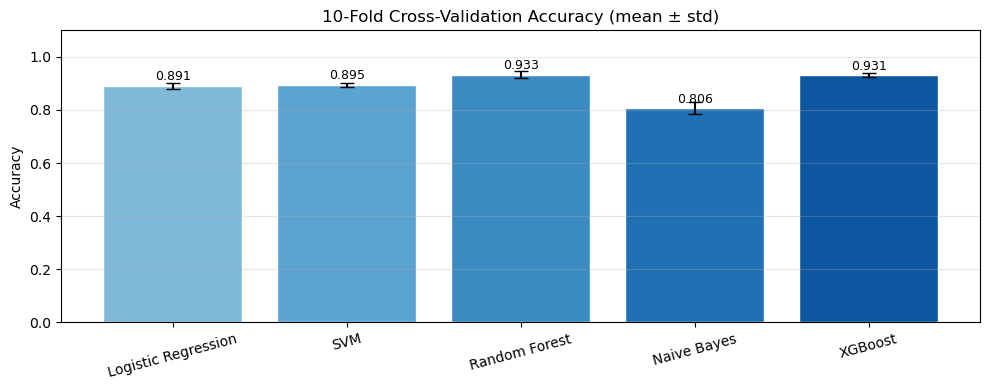

Saved: images/cv_accuracy_per_fold.png


In [104]:
kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

MODELS = {
    'Logistic Regression': lr,
    'SVM':                 svm,
    'Random Forest':       rf,
    'Naive Bayes':         nb,
    'XGBoost':             xgb_clf,
}

cv_results = {}
for name, model in MODELS.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")

# Bar chart: mean CV accuracy ± std
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

colors = plt.cm.Blues(np.linspace(0.45, 0.85, len(names)))
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, means, yerr=stds, color=colors, edgecolor='white', capsize=5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title(f'{CV_FOLDS}-Fold Cross-Validation Accuracy (mean ± std)', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/cv_accuracy_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/cv_accuracy_per_fold.png')

## Confusion Matrices
Each cell shows how many test partitions were assigned to each predicted genre.
Off-diagonal cells are misclassifications — useful for spotting which genres
get confused with each other.

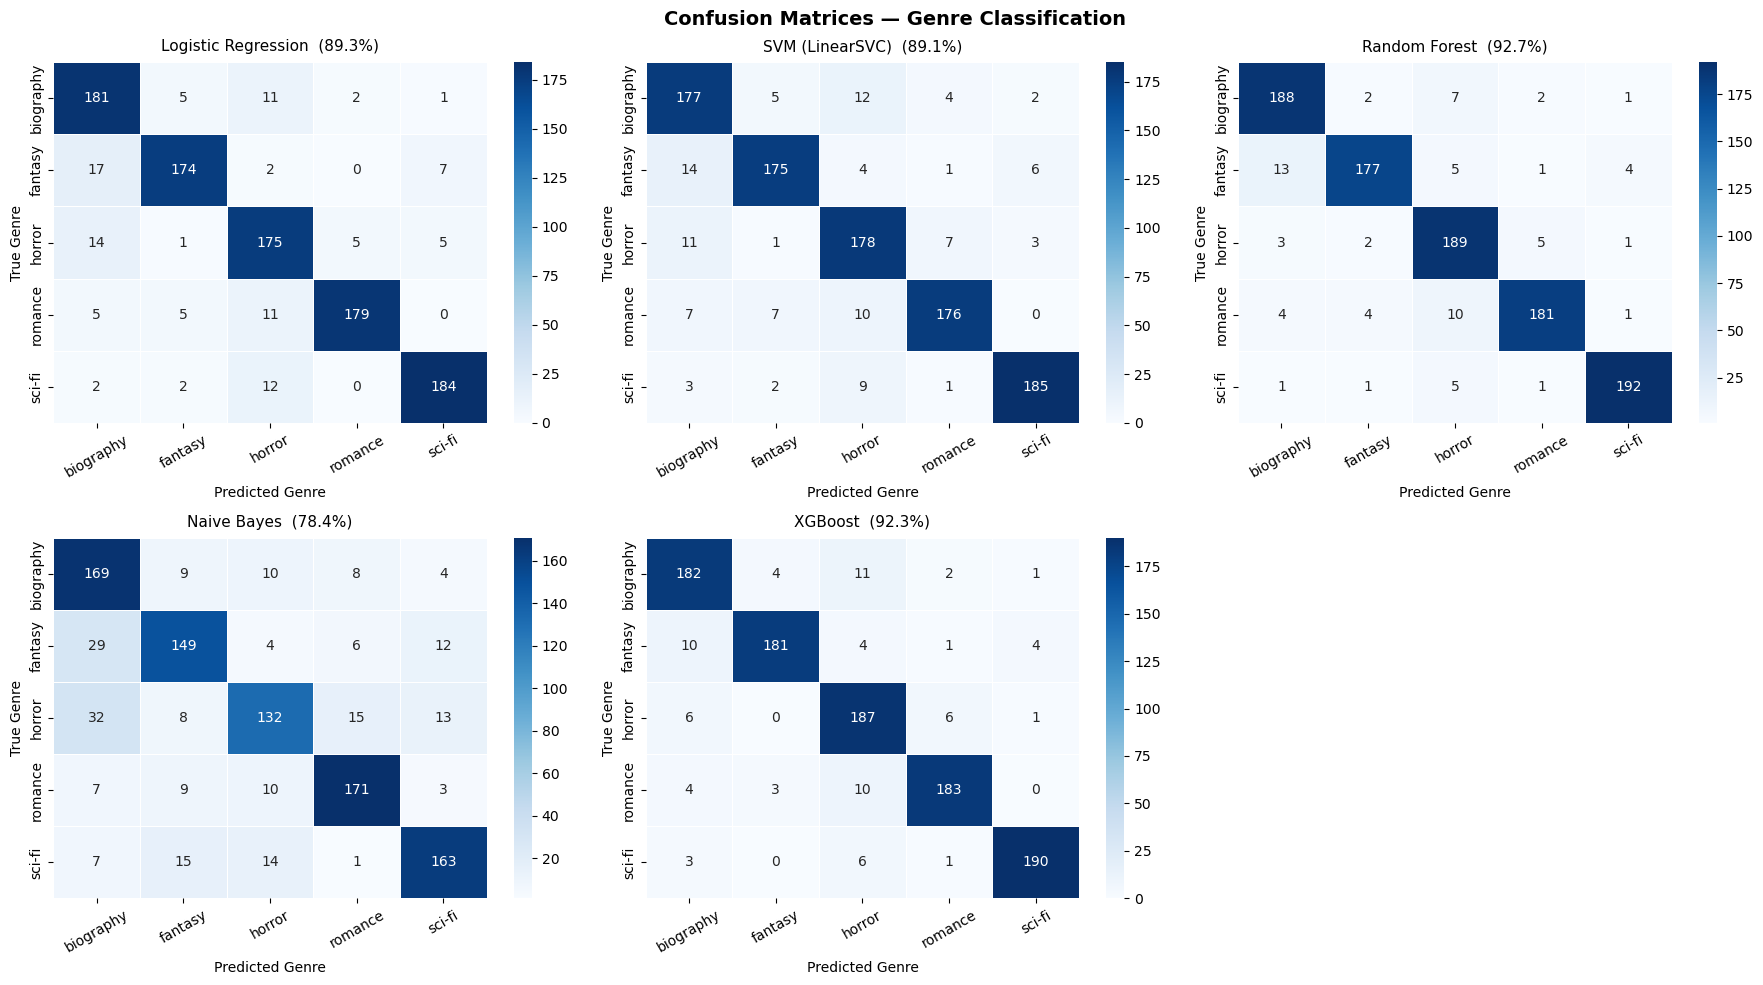

Saved: images/confusion_matrices.png


In [105]:
PREDS = {
    'Logistic Regression': y_pred_lr,
    'SVM (LinearSVC)':     y_pred_svm,
    'Random Forest':       y_pred_rf,
    'Naive Bayes':         y_pred_nb,
    'XGBoost':             y_pred_xgb,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (name, y_pred) in zip(axes_flat, PREDS.items()):
    cm = confusion_matrix(y_test, y_pred, labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                linewidths=0.5, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}  ({acc:.1%})', fontsize=11, pad=8)
    ax.set_xlabel('Predicted Genre')
    ax.set_ylabel('True Genre')
    ax.tick_params(axis='x', rotation=30)

axes_flat[-1].set_visible(False)
fig.suptitle('Confusion Matrices — Genre Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/confusion_matrices.png')

## Error Analysis
Inspect the actual misclassified partitions to understand *why* genres get confused.

In [106]:
def error_analysis(model_name, y_pred):
    """Print misclassified partitions with their true and predicted genres."""
    # Align predictions back to the original partition rows used in the test split
    test_indices = partitions.index[
        partitions.index.isin(
            partitions.iloc[
                list(range(len(partitions)))
            ].index
        )
    ]

    # Rebuild a results frame from the test split
    _, X_test_raw, _, y_test_raw = train_test_split(
        partitions['text'].values, partitions['genre'].values,
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=partitions['genre'].values
    )

    errors = pd.DataFrame({
        'text':      X_test_raw,
        'true':      y_test_raw,
        'predicted': y_pred,
    })
    errors = errors[errors['true'] != errors['predicted']]

    print(f"\n{'='*60}")
    print(f"  {model_name} — {len(errors)} misclassified partitions")
    print(f"{'='*60}")
    print(errors.groupby(['true','predicted']).size().rename('count').to_string())
    print(f"\n--- Sample misclassifications (up to 3 per pair) ---")
    for (true, pred), group in errors.groupby(['true','predicted']):
        for _, row in group.head(3).iterrows():
            print(f"\n[True: {true}] → [Predicted: {pred}]")
            print(f"  {row['text'][:200]}...")

error_analysis("Logistic Regression", y_pred_lr)
error_analysis("SVM", y_pred_svm)



  Logistic Regression — 107 misclassified partitions
true       predicted
biography  fantasy       5
           horror       11
           romance       2
           sci-fi        1
fantasy    biography    17
           horror        2
           sci-fi        7
horror     biography    14
           fantasy       1
           romance       5
           sci-fi        5
romance    biography     5
           fantasy       5
           horror       11
sci-fi     biography     2
           fantasy       2
           horror       12

--- Sample misclassifications (up to 3 per pair) ---

[True: biography] → [Predicted: fantasy]
  prospect remain'd of the Meredith's fulfilling their part of our agreement, because I thought myself under great obligations to them for what they had done, and would do if they could; but, if they fi...

[True: biography] → [Predicted: fantasy]
  shining; but as they listened they plainly heard the tinkling of many drops falling through the forest, and sliding from

## Save Trained Models
Serialises both models and the vectorizer so they can be loaded without re-training.

In [107]:
joblib.dump(lr,         'model_logistic_regression.pkl')
joblib.dump(svm,        'model_svm.pkl')
joblib.dump(rf,         'model_random_forest.pkl')
joblib.dump(nb,         'model_naive_bayes.pkl')
joblib.dump(xgb_clf,    'model_xgboost.pkl')
joblib.dump(vectorizer, 'FeatureTrainingData/vectorizer.pkl')
print("Saved: model_logistic_regression.pkl")
print("Saved: model_svm.pkl")
print("Saved: model_random_forest.pkl")
print("Saved: model_naive_bayes.pkl")
print("Saved: model_xgboost.pkl")
print("Saved: FeatureTrainingData/vectorizer.pkl")

Saved: model_logistic_regression.pkl
Saved: model_svm.pkl
Saved: model_random_forest.pkl
Saved: model_naive_bayes.pkl
Saved: model_xgboost.pkl
Saved: FeatureTrainingData/vectorizer.pkl


## Quick Predict on New Text
Load the saved models and classify an arbitrary passage.

In [108]:
vec     = joblib.load('FeatureTrainingData/vectorizer.pkl')
lr2     = joblib.load('model_logistic_regression.pkl')
svm2    = joblib.load('model_svm.pkl')
rf2     = joblib.load('model_random_forest.pkl')
nb2     = joblib.load('model_naive_bayes.pkl')
xgb2    = joblib.load('model_xgboost.pkl')

sample_text = [
    "The robot spaceship launched into the dark void of deep space as the crew "
    "prepared for their mission to the distant star system far beyond the galaxy."
]

X_sample = vec.transform(sample_text)
for name, model in [('LR', lr2), ('SVM', svm2), ('RF', rf2), ('NB', nb2), ('XGBoost', xgb2)]:
    print(f"{name:10}: {model.predict(X_sample)[0]}")

probs = pd.Series(lr2.predict_proba(X_sample)[0], index=lr2.classes_)
print(f"\nLR class probabilities:")
print(probs.sort_values(ascending=False).to_string())

LR        : sci-fi
SVM       : sci-fi
RF        : sci-fi
NB        : sci-fi
XGBoost   : sci-fi

LR class probabilities:
sci-fi       0.932356
horror       0.044236
biography    0.012012
romance      0.010180
fantasy      0.001216
